In [3]:
from dotenv import load_dotenv

load_dotenv()

True

In [6]:
from langchain_tavily import TavilySearch

tavily = TavilySearch(max_results=3) 

In [11]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model = 'gemini-3.5-flash-lite')

In [47]:
def add(numbers: list[int]) -> int:
    """Add a list of integers together with any number of input for addition.
    Input:
        numbers: list of integers (e.g., [10, 20, 30])
    
    Output:
        The sum of all integers in the list.
    """
    return sum(numbers)

import math

def multiply(numbers: list[int]) -> int:
    """Multiply a list of integers together with any number of input for multiplication.
    Input:
        numbers: list of integers (e.g., [2, 5, 10])
    Output:
        The product of all integers in the list.
    """
    return math.prod(numbers)

tools = [tavily, add, multiply]

In [48]:
llm_with_tools = llm.bind_tools(tools)

In [49]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import  add_messages

from typing import TypedDict

class State(TypedDict):
    messages : Annotated[list, add_messages]


def llm_calling(state : State):
    return {"messages" : llm_with_tools.invoke(state['messages'])}




In [50]:
from langgraph.prebuilt import tools_condition, ToolNode

graph_builder = StateGraph(State)

graph_builder.add_node("llm_calling", llm_calling)
graph_builder.add_node("tools", ToolNode(tools))


graph_builder.add_edge(START, "llm_calling")
graph_builder.add_conditional_edges("llm_calling", tools_condition)
graph_builder.add_edge("tools", END)

graph = graph_builder.compile()


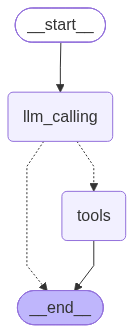

In [51]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [60]:
response = graph.invoke({"messages" : ["What is sum of 1 and 1 and product of 3 and 6 ? How is todays wheather in Chennai?"]})

response

{'messages': [HumanMessage(content='What is sum of 1 and 1 and product of 3 and 6 ? How is todays wheather in Chennai?', additional_kwargs={}, response_metadata={}, id='f0b368b0-55ed-48eb-9dc2-bc8276ff7d8a'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "weather in Chennai today"}'}, '__gemini_function_call_thought_signatures__': {'call_5135107': 'El4KXAERTTIPg+BVjWRk99cEgsZTmPHOtTl85s5Hoh8Qt8z1eQ9gPGGzSW2Gu/CmakweLqrZfezcl0AfraJm6+ICJLLL6Kgu5QP/fVsFQpfTZaAnY2u3RpXVozPkdMS6'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a02f28-4b8b-7352-9dd7-35eb970b572a-0', tool_calls=[{'name': 'add', 'args': {'numbers': [1, 1]}, 'id': 'call_5135107', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'numbers': [3, 6]}, 'id': 'call_5135108', 'type': 'tool_call'}, {'name': 'tavily_search', 'args': {'query': 'weather in Chennai 

In [61]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is sum of 1 and 1 and product of 3 and 6 ? How is todays wheather in Chennai?
================================== Ai Message ==================================

[]
Tool Calls:
  add (call_5135107)
 Call ID: call_5135107
  Args:
    numbers: [1, 1]
  multiply (call_5135108)
 Call ID: call_5135108
  Args:
    numbers: [3, 6]
  tavily_search (call_5135109)
 Call ID: call_5135109
  Args:
    query: weather in Chennai today
================================= Tool Message =================================
Name: add

2
================================= Tool Message =================================
Name: multiply

18
================================= Tool Message =================================
Name: tavily_search

{"query": "weather in Chennai today", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in Chennai", "url": "https://www.weatherapi.com/", "content": "{'lo